## 🚗 TripFare : Predicting Urban Taxi Fare with Machine Learning


In [5]:
!pip install pandas numpy matplotlib seaborn scikit-learn streamlit joblib scipy

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [7]:
sns.set(style="whitegrid")

### STEP 1: Data Collection

In [8]:
df = pd.read_csv('taxi_fare.csv')
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,-73.976746,40.765152,1,N,-74.004265,40.746128,1,9.0,0.5,0.5,2.05,0.00,0.3,12.35
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,-73.983482,40.767925,1,N,-74.005943,40.733166,1,11.0,0.5,0.5,3.05,0.00,0.3,15.35
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,-73.782021,40.644810,1,N,-73.974541,40.675770,1,54.5,0.5,0.5,8.00,0.00,0.3,63.80
3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,-73.863419,40.769814,1,N,-73.969650,40.757767,1,31.5,0.0,0.5,3.78,5.54,0.3,41.62
4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,-73.971741,40.792183,3,N,-74.177170,40.695053,1,98.0,0.0,0.0,0.00,15.50,0.3,113.80


### STEP 2: Data Understanding

In [9]:
# 1. Shape of data (rows, columns)
print(df.shape)

(212345, 18)


In [10]:
# 2. Column names
print(df.columns.tolist())

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag', 'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount']


In [11]:
# 3. Data types of each column
print(df.dtypes)

VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
pickup_longitude         float64
pickup_latitude          float64
RatecodeID                 int64
store_and_fwd_flag        object
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object


In [12]:
# 4. Basic statistics (mean, min, max, etc.)
print(df.describe())

            VendorID  passenger_count  pickup_longitude  pickup_latitude  \
count  212345.000000    212345.000000     212345.000000    212345.000000   
mean        1.708338         1.766493        -73.112122        40.279405   
std         0.454529         1.469647          7.936633         4.370714   
min         1.000000         0.000000       -121.933327         0.000000   
25%         1.000000         1.000000        -73.990891        40.740292   
50%         2.000000         1.000000        -73.979469        40.755989   
75%         2.000000         2.000000        -73.963295        40.770283   
max         2.000000         6.000000          0.000000        42.786934   

          RatecodeID  dropoff_longitude  dropoff_latitude   payment_type  \
count  212345.000000      212345.000000     212345.000000  212345.000000   
mean        1.034152         -73.144178         40.295648       1.324943   
std         0.494699           7.794599          4.293031       0.478255   
min        

In [13]:
# 5. Check for missing values
print(df.isnull().sum())

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64


In [14]:
# 6. Check for duplicate rows
print(df.duplicated().sum())

0


In [15]:
# 7. Quick info summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212345 entries, 0 to 212344
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               212345 non-null  int64  
 1   tpep_pickup_datetime   212345 non-null  object 
 2   tpep_dropoff_datetime  212345 non-null  object 
 3   passenger_count        212345 non-null  int64  
 4   pickup_longitude       212345 non-null  float64
 5   pickup_latitude        212345 non-null  float64
 6   RatecodeID             212345 non-null  int64  
 7   store_and_fwd_flag     212345 non-null  object 
 8   dropoff_longitude      212345 non-null  float64
 9   dropoff_latitude       212345 non-null  float64
 10  payment_type           212345 non-null  int64  
 11  fare_amount            212345 non-null  float64
 12  extra                  212345 non-null  float64
 13  mta_tax                212345 non-null  float64
 14  tip_amount             212345 non-nu

In [16]:
# Drop exact duplicate rows
df = df.drop_duplicates()

# Drop rows where target variable is missing (can't train without it)
df = df.dropna(subset=['total_amount'])

### STEP 3: Feature Engineering (Create New Columns)

In [17]:
# Convert datetime columns properly

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [18]:
# Convert pickup time from UTC to EDT (Eastern time)

df['tpep_pickup_datetime'] = df['tpep_pickup_datetime'].dt.tz_localize('UTC').dt.tz_convert('US/Eastern')
df['tpep_dropoff_datetime'] = df['tpep_dropoff_datetime'].dt.tz_localize('UTC').dt.tz_convert('US/Eastern')

In [19]:
# Trip distance using the Haversine formula

def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c   # Earth's radius in km
    return km

df['trip_distance'] = haversine(
    df['pickup_longitude'], df['pickup_latitude'],
    df['dropoff_longitude'], df['dropoff_latitude']
)

In [20]:
# Trip duration (in minutes)

df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

In [21]:
# Pickup day (weekday name) and weekend flag

df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['is_weekend'] = df['tpep_pickup_datetime'].dt.dayofweek.isin([5, 6]).astype(int)

In [22]:
# Pickup hour, AM/PM, and night flag

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['am_pm'] = df['tpep_pickup_datetime'].dt.strftime('%p')

# Night = between 10 PM and 5 AM
df['is_night'] = df['pickup_hour'].apply(lambda h: 1 if (h >= 22 or h < 5) else 0)

In [23]:
# Extra useful features

# Fare per mile / per minute (helpful for later analysis)
df['fare_per_mile'] = df['fare_amount'] / df['trip_distance'].replace(0, np.nan)
df['fare_per_minute'] = df['fare_amount'] / df['trip_duration_min'].replace(0, np.nan)

# Month of the trip
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

### STEP 4: Exploratory Data Analysis (EDA)

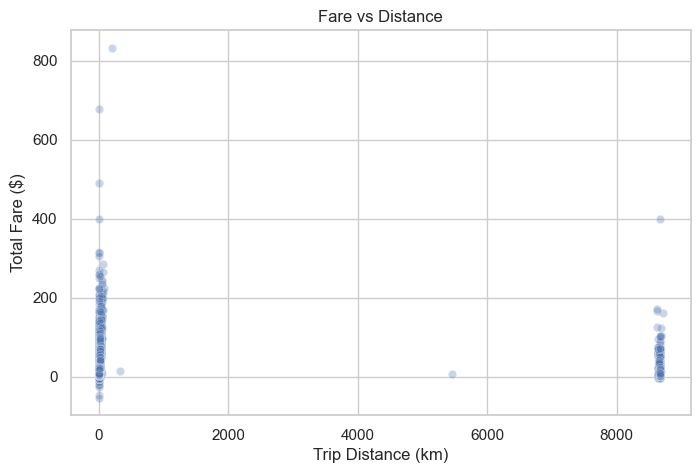

In [24]:
# Fare vs Distance

plt.figure(figsize=(8,5))
sns.scatterplot(x='trip_distance', y='total_amount', data=df, alpha=0.3)
plt.title('Fare vs Distance')
plt.xlabel('Trip Distance (km)')
plt.ylabel('Total Fare ($)')
plt.show()

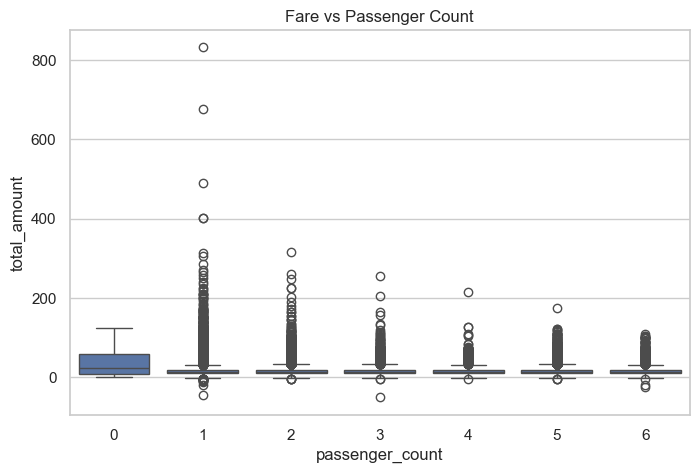

In [25]:
# Fare vs Passenger Count

plt.figure(figsize=(8,5))
sns.boxplot(x='passenger_count', y='total_amount', data=df)
plt.title('Fare vs Passenger Count')
plt.show()

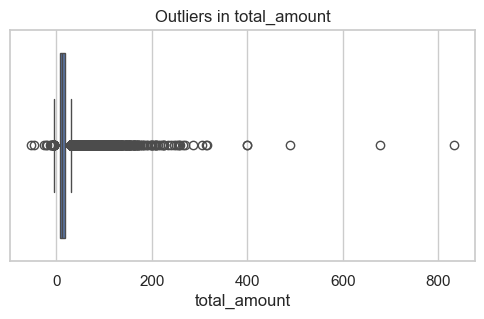

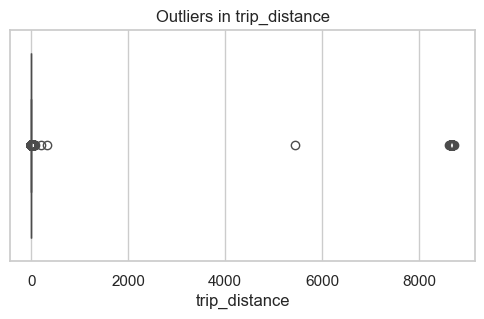

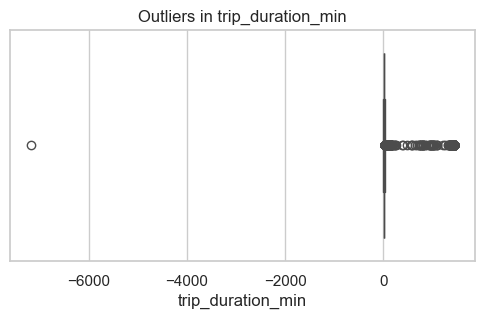

In [26]:
# Outlier detection (boxplots)

for col in ['total_amount', 'trip_distance', 'trip_duration_min']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.show()

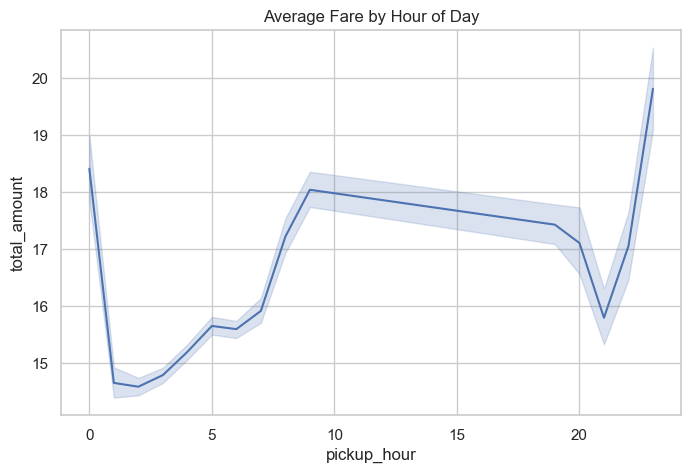

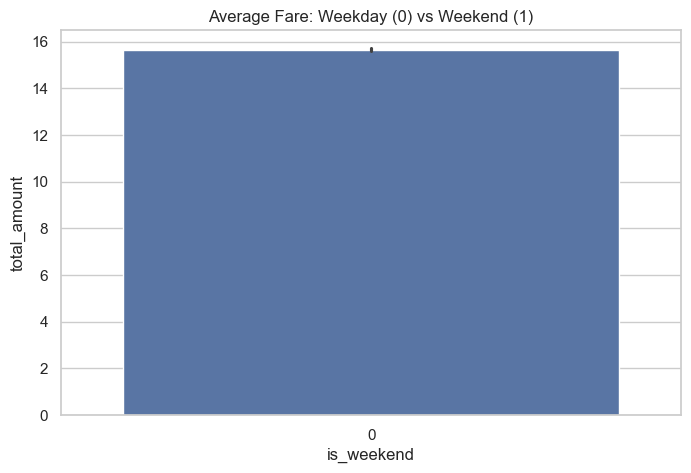

In [27]:
# Fare by time of day, weekday vs weekend

plt.figure(figsize=(8,5))
sns.lineplot(x='pickup_hour', y='total_amount', data=df, estimator='mean')
plt.title('Average Fare by Hour of Day')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x='is_weekend', y='total_amount', data=df)
plt.title('Average Fare: Weekday (0) vs Weekend (1)')
plt.show()

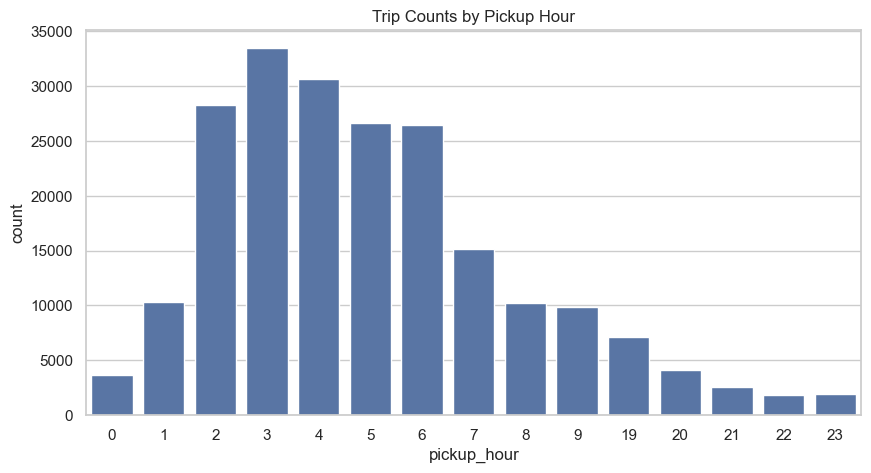

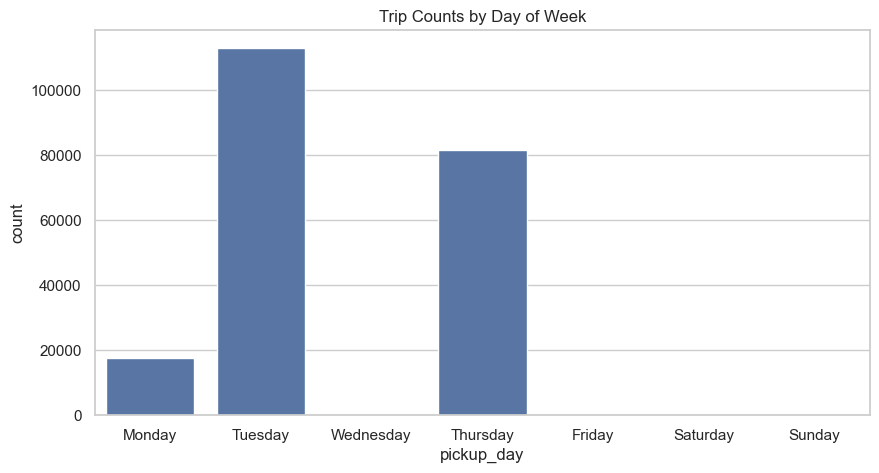

In [28]:
# Trip counts by hour and day (demand patterns)

plt.figure(figsize=(10,5))
sns.countplot(x='pickup_hour', data=df)
plt.title('Trip Counts by Pickup Hour')
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x='pickup_day', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Trip Counts by Day of Week')
plt.show()

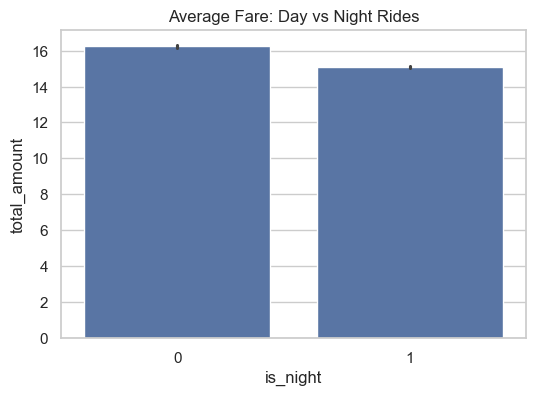

In [29]:
# Night rides impact

plt.figure(figsize=(6,4))
sns.barplot(x='is_night', y='total_amount', data=df)
plt.title('Average Fare: Day vs Night Rides')
plt.show()

### STEP 5: Data Transformation

In [30]:
# Remove impossible / bad values first

df = df[(df['total_amount'] > 0) & (df['total_amount'] < 500)]
df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 100)]
df = df[(df['trip_duration_min'] > 0) & (df['trip_duration_min'] < 180)]
df = df[df['passenger_count'] > 0]

In [31]:
# Handle outliers using IQR method

Q1 = df['total_amount'].quantile(0.25)
Q3 = df['total_amount'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['total_amount'] >= Q1 - 1.5*IQR) & (df['total_amount'] <= Q3 + 1.5*IQR)]

In [32]:
# Fix skewness (make distributions more normal)

print("Skew before:", df['trip_distance'].skew())

df['trip_distance_log'] = np.log1p(df['trip_distance'])   # log1p handles 0 values safely
df['trip_duration_log'] = np.log1p(df['trip_duration_min'])

print("Skew after:", df['trip_distance_log'].skew())

Skew before: 1.846685612843572
Skew after: 0.5314978543484014


In [33]:
# Encode categorical variables

# One-hot encode simple categories
df = pd.get_dummies(df, columns=['am_pm', 'pickup_day', 'payment_type'], drop_first=True)


### STEP 6: Feature Selection

total_amount             1.000000
fare_amount              0.975222
trip_duration_min        0.880498
trip_duration_log        0.853840
trip_distance_log        0.841438
trip_distance            0.835114
tip_amount               0.584043
tolls_amount             0.086960
pickup_hour              0.074511
extra                    0.042446
VendorID                 0.019441
dropoff_longitude        0.010180
passenger_count          0.008614
pickup_longitude         0.008444
improvement_surcharge    0.001361
fare_per_mile            0.001213
RatecodeID              -0.001361
mta_tax                 -0.003623
is_night                -0.047868
pickup_month            -0.054229
fare_per_minute         -0.060629
pickup_latitude         -0.066233
dropoff_latitude        -0.126555
is_weekend                    NaN
Name: total_amount, dtype: float64


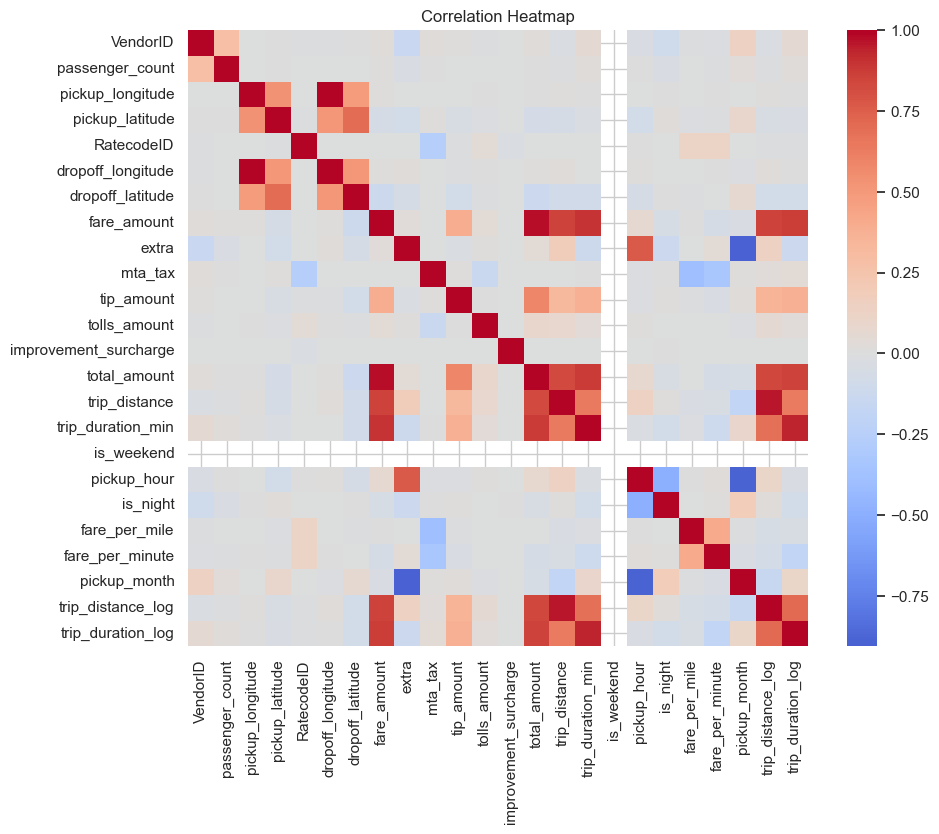

In [34]:
# Correlation with target

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()['total_amount'].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

fare_amount              9.355911e-01
tip_amount               6.195613e-02
tolls_amount             1.836031e-03
extra                    4.900150e-04
pickup_hour              1.472859e-05
fare_per_minute          1.215130e-05
dropoff_latitude         1.187516e-05
pickup_longitude         1.163921e-05
pickup_latitude          1.157513e-05
fare_per_mile            1.099565e-05
pickup_month             9.685371e-06
dropoff_longitude        9.059976e-06
trip_duration_min        8.984529e-06
trip_distance            7.715072e-06
trip_distance_log        6.941904e-06
trip_duration_log        6.842521e-06
is_night                 1.216381e-06
passenger_count          1.213761e-06
VendorID                 8.463075e-07
mta_tax                  7.445991e-07
RatecodeID               5.451192e-07
improvement_surcharge    1.098644e-08
is_weekend               0.000000e+00
dtype: float64


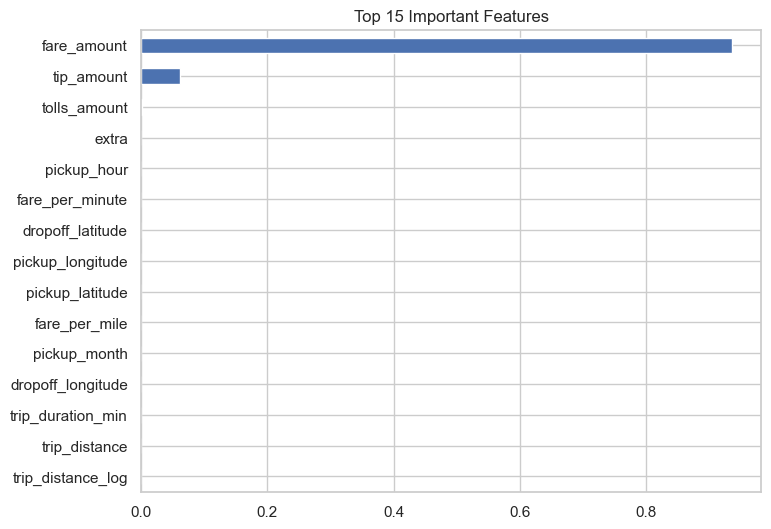

In [35]:
# Feature importance from Random Forest

from sklearn.ensemble import RandomForestRegressor

# Drop columns ragr we  won't use as inputs (IDs, raw datetimes, target itself)
drop_cols = ['total_amount', 'tpep_pickup_datetime', 'tpep_dropoff_datetime']
X_temp = numeric_df.drop(columns=[c for c in drop_cols if c in numeric_df.columns])
y_temp = df['total_amount']

rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_temp.fit(X_temp, y_temp)

importances = pd.Series(rf_temp.feature_importances_, index=X_temp.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,6))
importances.head(15).plot(kind='barh')
plt.title('Top 15 Important Features')
plt.gca().invert_yaxis()
plt.show()


### STEP 7: Model Building

In [36]:
# Prepare final X (inputs) and y (target)

final_features = importances.head(15).index.tolist()   # pick top features
X = df[final_features]
y = df['total_amount']

In [37]:
# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
# Scale features (needed for Linear/Ridge/Lasso)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
# Build and compare at least 5 models

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    # Linear-type models use scaled data; tree models can use raw data
    if name in ['Linear Regression', 'Ridge', 'Lasso']:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)

    results.append([name, r2, mse, rmse, mae])

results_df = pd.DataFrame(results, columns=['Model', 'R2', 'MSE', 'RMSE', 'MAE'])
results_df = results_df.sort_values(by='R2', ascending=False)
print(results_df)

               Model        R2       MSE      RMSE       MAE
1              Ridge  0.999997  0.000084  0.009189  0.000631
0  Linear Regression  0.999997  0.000085  0.009193  0.000642
3      Random Forest  0.999805  0.006130  0.078294  0.004911
4  Gradient Boosting  0.999359  0.020149  0.141948  0.097907
2              Lasso  0.952156  1.503829  1.226307  0.948953


### STEP 8: Hyperparameter Tuning

In [40]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# Evaluate tuned model
preds = best_model.predict(X_test)
print("Tuned R2:", r2_score(y_test, preds))
print("Tuned RMSE:", np.sqrt(mean_squared_error(y_test, preds)))

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned R2: 0.9998049766106111
Tuned RMSE: 0.07829387577534899


### STEP 9: Finalize and Save the Best Model

In [41]:
import joblib

joblib.dump(best_model, 'best_taxi_fare_model.pkl')
joblib.dump(scaler, 'scaler.pkl')          # only needed if best model was linear/ridge/lasso
joblib.dump(final_features, 'features.pkl')  # save which columns the model expects

['features.pkl']